# Midpoint Analysis Plots Only

This notebook only loads saved posterior files and makes plots.
It does not rerun the expensive grid generation step.

In [42]:
%load_ext autoreload
%autoreload 2

import numpy as np
from pathlib import Path

import corner
import emcee
import matplotlib.pyplot as plt
import sys
import pickle

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

from mcmc_runner_a import draw_grid_samples

plt.style.use('../../../configurations/style.mplstyle')

OUTPUT_ROOT_BASELINE         = Path('../Output_files')
BASELINE_ROOT       = OUTPUT_ROOT_BASELINE / 'baseline_flat_midpoint_alpha'
OUTPUT_ROOT = Path('Output_files')
GEOM_EFF_NAME       = 'geometric_efficiency_flat_midpoint'
GEOM_EFF_ALL        = ['geometric_efficiency_flat_midpoint', 'geometric_efficiency_fixed', 'geom_eff_func_lognormal']

ALPHA_test          = 'A0.5'
ALPHA_all           = ['A0.5', 'A1.0']
FJ_LIST             = [0.01, 0.1, 1.0]#[0.1, 0.5, 1.0]
NSBH_POPULATIONS    = ['fiducial_delayed_cut_sfho', 'fiducial_delayed_cut_dd2']

BASELINE_BACKEND = BASELINE_ROOT.with_name(f'{BASELINE_ROOT.name}_{ALPHA_test}') / 'emcee.h5'
assert BASELINE_BACKEND.is_file(), f'Missing baseline backend: {BASELINE_BACKEND}'

with open(OUTPUT_ROOT / "results_by_fj.pkl", "rb") as f:
    results_by_fj = pickle.load(f)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
IMAGES_FOLDER = Path("IMAGES")
IMAGES_FOLDER.mkdir(exist_ok=True)

FIGSIZE_COL         = (3.46, 2.14) # textwidth plot
FIGSIZE_ROW         = (7.08, 4.38)
FONTSIZE_UNIVERSAL  = 16

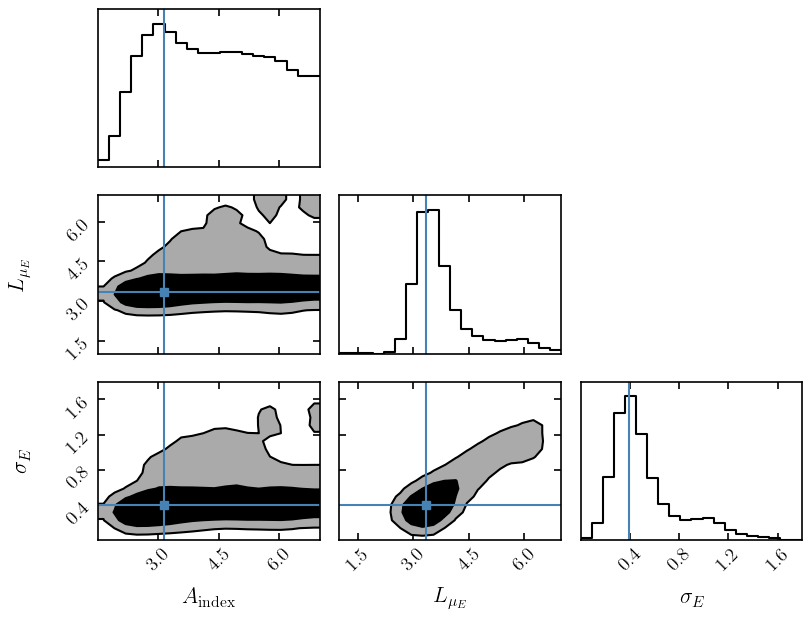

In [44]:
backend = emcee.backends.HDFBackend(BASELINE_BACKEND)
samples = backend.get_chain(flat=True, discard=3000, thin=10)
logfn = backend.get_log_prob(flat=True, discard=3000, thin=10)
arg_max = np.argmax(logfn)

if samples.shape[1] >= 4:
    bns_corner_samples = samples[:, [0, 2, 3]]
    bns_corner_labels = [r'$A_{\rm index}$', r'$L_{\mu_E}$', r'$\sigma_E$']
else:
    bns_corner_samples = samples
    bns_corner_labels = [f'param {i + 1}' for i in range(samples.shape[1])]

ranges = [
    (1.5, 7),  # A_index
    (1, 7),  # L_mu_E
    (0.0, 1.8),   # sigma_E
]
bns_corner_fig = corner.corner(
    bns_corner_samples,
    labels=bns_corner_labels,
    color='k',
    bins=20,
    smooth=1,
    smooth1d=1,
    plot_datapoints=False,
    plot_density=True,
    fill_contours=True,
    #use maximum for truth
    truths=[samples[arg_max, 0], samples[arg_max, 2], samples[arg_max, 3]],
    #quantiles=[0.16, 0.5, 0.84],
    show_titles=False,
    title_kwargs={'fontsize': 11},
    label_kwargs={'fontsize': FONTSIZE_UNIVERSAL},
    levels= [0.68, 0.95],
    range=ranges,
)
#change corner plot figsize
scale_factor = 3
figsize_bns_corner = (FIGSIZE_COL[0] * scale_factor * 0.8, FIGSIZE_COL[1] * scale_factor)
bns_corner_fig.set_size_inches(figsize_bns_corner)
# set ticks
for ax in bns_corner_fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_UNIVERSAL-2)
plt.tight_layout()
plt.savefig(IMAGES_FOLDER / f'midpoint_corner_plot_{ALPHA_test}.pdf', bbox_inches='tight')
plt.show()

Target theta for fj = 1.0: 10.0000


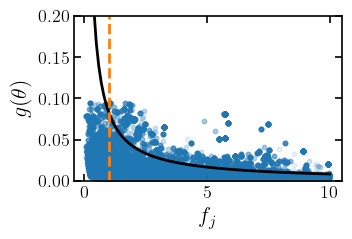

In [79]:
#samples.shape
from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint, geometric_efficiency_fixed, create_geometric_efficiency_lognormal_interpolator
#samples[:, 4]
geom_eff_func_midpoint          = geometric_efficiency_flat_midpoint
geom_eff_func_fixed             = geometric_efficiency_fixed
geom_eff_func_interp            = create_geometric_efficiency_lognormal_interpolator()
def geom_eff_func_lognormal(x): return geom_eff_func_interp(x)

geom_current = geom_eff_func_midpoint

theta_samples   = samples[:, 4]
geom_samples    = geom_current(theta_samples)
fj_samples      = samples[:, 5]

# fit geom_samples * fj_samples  = const ie. geom_samples = const / fj_samples, where the 90% quantile of fj < 9
const = np.quantile(geom_samples * fj_samples, 0.9)
plt_fj = np.linspace(0.1, 10, 100)
plt_geom = const / plt_fj
plt.figure(figsize=FIGSIZE_COL)
plt.plot(plt_fj, plt_geom, color='k', lw=2, label='90% quantile')
plt.scatter(fj_samples, geom_samples, color='C0', alpha=0.1, s=10, label='Samples')
plt.xlabel(r'$f_j$', fontsize=FONTSIZE_UNIVERSAL)
plt.ylabel(r'$g(\theta)$', fontsize=FONTSIZE_UNIVERSAL)
plt.ylim(0, 0.2)

#theta at which geom_samples * fj_samples = 1 ie. given geom(theta) solve for fj(theta) = 1 / geom(theta)
fj_target = 1.0

theta_target = np.interp(fj_target, plt_geom, plt_fj)
plt.axvline(x=fj_target, color='C1', lw=2, ls='--', label=r'$f_j = 1$')
print(f'Target theta for fj = {fj_target}: {theta_target:.4f}')

Maximum log-likelihood value: -5.45019470747005
Maximum log-likelihood value: -5.0319680340731665


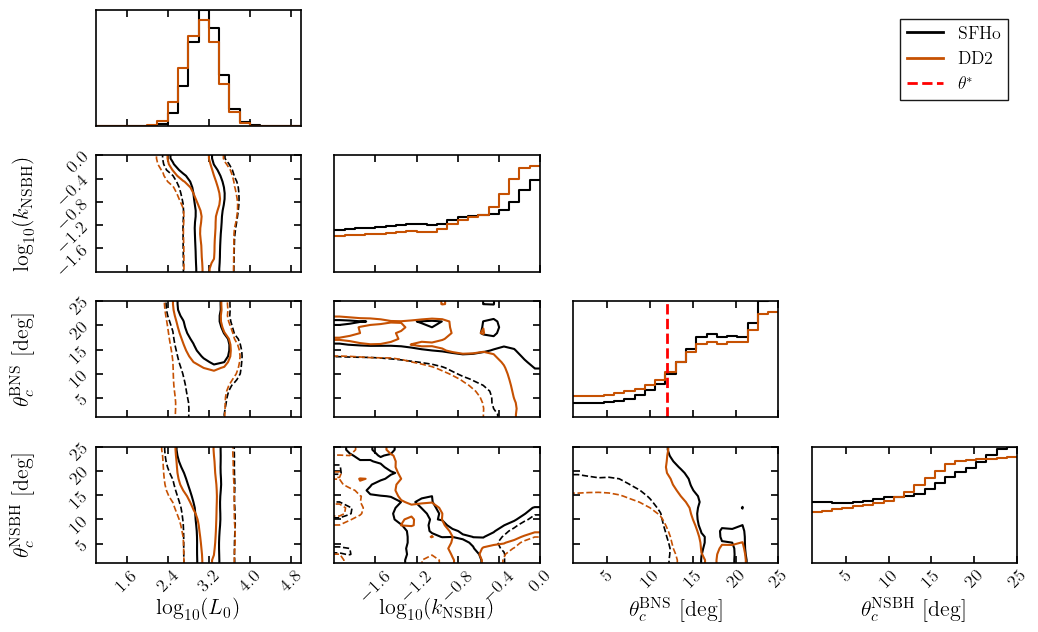

In [90]:
grid_labels = [
    r'$\log_{10}(L_0)$',
    r'$\log_{10}(k_{\mathrm{NSBH}})$',
    r'$\theta_c^{\mathrm{BNS}}$ [deg]',
    r'$\theta_c^{\mathrm{NSBH}}$ [deg]',
]
grid_ranges = [
    (1, 5),
    (-2, 0),
    (1, 25),
    (1, 25),
]

alpha = ALPHA_test
grid_files = results_by_fj[0.1]['grid_files']
#samples_sfho, _, _ = draw_grid_samples(grid_files[0])
#samples_dd2, _, _ = draw_grid_samples(grid_files[2])

ALPHA_VALUES = ["A0.5", "A1.0"]
alpha_idx = ALPHA_VALUES.index(ALPHA_test)

samples_sfho, _, _ = draw_grid_samples(grid_files[alpha_idx])
samples_dd2, _, _ = draw_grid_samples(
    grid_files[len(ALPHA_VALUES) + alpha_idx]
)

common_args = {
    'labels': grid_labels,
    'bins': 20,
    'smooth': 1,
    'smooth1d': 1,
    'range': grid_ranges,
    'plot_datapoints': False,
    'plot_density': False,
    'fill_contours': False,
    'no_fill_contours': True,
    'levels': [0.68, 0.95],
    'title_kwargs': {'fontsize': 11},
    'label_kwargs': {'fontsize': FONTSIZE_UNIVERSAL},
}

contour_style = {
    'linestyles': ['--', '-'],  # 95% dashed, 68% solid
    'linewidths': [1.2, 1.5],
}

scale_factor = 1.5
figsize_custom = (FIGSIZE_ROW[0] * scale_factor, FIGSIZE_ROW[1] * scale_factor)
#set axseparation to be less
fig_in = plt.figure(figsize=figsize_custom)

fig = corner.corner(
    samples_sfho,
    color='k',
    contour_kwargs={**contour_style, 'colors': 'k'},
    fig=fig_in,
    **common_args,
)

#(#c65102)
color2 = '#c65102'
corner.corner(
    samples_dd2,
    color=color2,
    contour_kwargs={**contour_style, 'colors': color2},
    fig=fig,
    **common_args,
)
axes = fig.get_axes()
axes[10].axvline(x=12, color='r', lw=2, ls='--', label=r'$\theta^*$')
#theta_median_new = np.median(samples_sfho[:, 2])
#axes[10].axvline(x=theta_median_new, color='C0', lw=2, ls='--', label=r'$\theta_{\rm median}$')
legend_handles = [
    plt.Line2D([0], [0], color='k', lw=2, label='SFHo'),
    plt.Line2D([0], [0], color=color2, lw=2, label='DD2'),
    plt.Line2D([0], [0], color='r', lw=2, ls='--', label=r'$\theta^*$'),
    #plt.Line2D([0], [0], color='C0', lw=2, ls='--', label=r'$\theta_{\rm median}$')
]
axes[3].legend(handles=legend_handles, loc='upper right')


fig.tight_layout()
fig.savefig(IMAGES_FOLDER / f'midpoint_corner_plot_{ALPHA_test}_both_EOS.pdf', bbox_inches='tight')
plt.show()

# id = 10

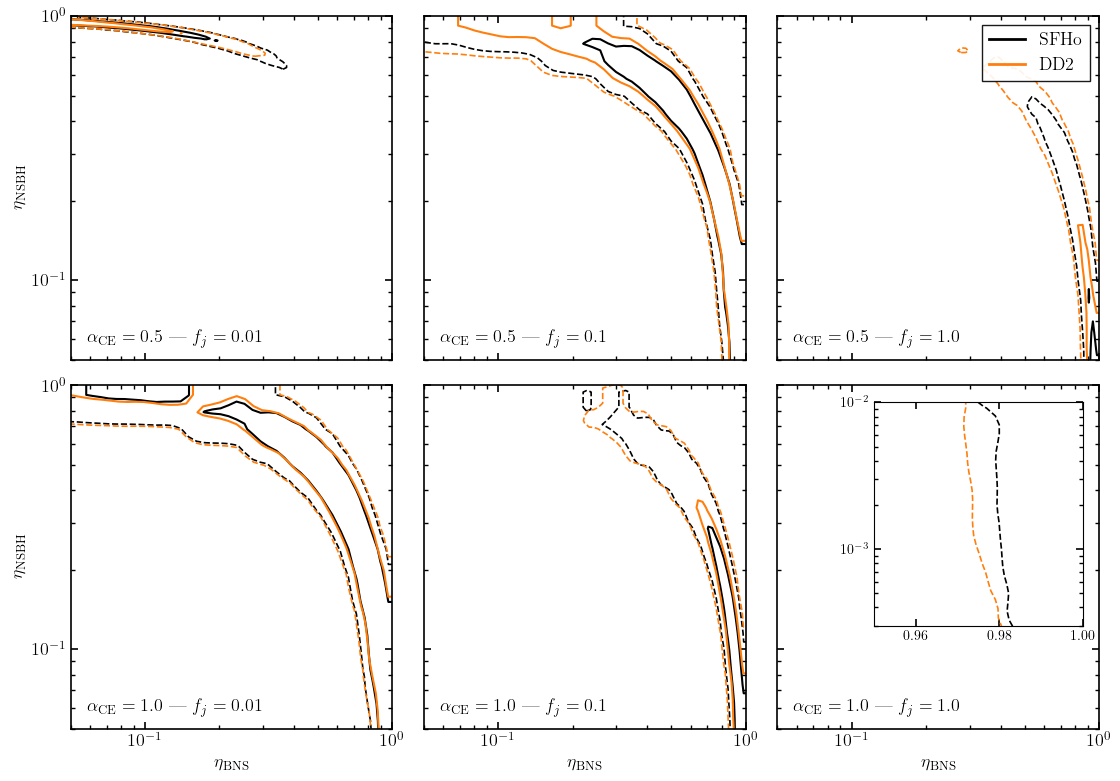

In [122]:
def plot_posterior_grid(
        dictionary_of_results,
        fj_list,
        alpha_list,
        nsbh_populations,
        swap_axes=False,
        bins=50,
        levels=(0.68, 0.95),
):
    """Plot 2D posterior rate contours in a fj-by-alpha grid."""
    LOG = True
    x_min = y_min = 0
    x_min_plot = y_min_plot = 0
    if LOG == True: 
        x_min = y_min = 1e-4    
        x_min_plot = y_min_plot = 0.5e-1

    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list
    rows = len(row_values)
    cols = len(col_values)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    population_colors = ["k", "C1", "C2", "C3"]



    for row_idx, row_value in enumerate(row_values):
        for col_idx, col_value in enumerate(col_values):

            alpha = col_value if swap_axes else row_value
            fj = row_value if swap_axes else col_value
            ax = axes[row_idx, col_idx]
            
            
            is_last_panel = row_idx == rows - 1 and col_idx == cols - 1
            # Create exactly one inset for this panel.
            axins = None
            if is_last_panel:
                #make inset occupy at least half of the panel
                bounds = [0.3, 0.3, 0.65, 0.65]
                axins = ax.inset_axes(
                    #[0.48, 0.48, 0.48, 0.48],
                    bounds,
                    facecolor="white",
                    zorder=10,

                )

            for pop_idx, population in enumerate(nsbh_populations):
                x, y = dictionary_of_results[(fj, alpha, population)]["R_BNS"], dictionary_of_results[(fj, alpha, population)]["R_NSBH"]
                total = x + y
                x = x / total
                y = y / total
                
                if LOG:
                    x = np.clip(x, x_min, 1)
                    y = np.clip(y, y_min, 1)

                color = population_colors[pop_idx % len(population_colors)]
                hist_kwargs = dict(
                    color=color,
                    plot_datapoints=False,
                    plot_density=False,
                    plot_contours=True,
                    no_fill_contours=False,
                    bins=bins,
                    smooth=1,
                    smooth1d=0,
                    levels=list(levels),
                    axes_scale=["log", "log"] if LOG else ["linear", "linear"],
                )
                common_args = {
                    "bins": bins,
                    "smooth": 1,
                    "plot_datapoints": False,
                    "plot_density": False,
                    "fill_contours": False,
                    "no_fill_contours": True,
                    "levels": [0.68, 0.95],
                    "axes_scale":["log", "log"] if LOG else ["linear", "linear"],
                }
                contour_style = {
                    "linestyles": ["--", "-"],  # 95% dashed, 68% solid
                    "linewidths": [1.2, 1.5],
                }

                #corner.hist2d(x, y, ax=ax, **hist_kwargs)

                corner.hist2d(
                    x,
                    y,
                    ax=ax,
                    color=color,
                    contour_kwargs={**contour_style, "colors": color},
                    **common_args,
                )

                if axins is not None:
                    #corner.hist2d(x, y, ax=axins, **hist_kwargs)
                    corner.hist2d(
                        x,
                        y,
                        ax=axins,
                        color=color,
                        contour_kwargs={**contour_style, "colors": color},
                        **common_args,
                    )

                if LOG == True:
                    ax.set_xscale('log')
                    ax.set_yscale('log')

            if axins is not None:
                axins.set_xlim(0.95, 1.0)
                axins.set_ylim(3e-4, 1e-2)

                axins.set_xscale("linear")
                axins.set_yscale("log")

                axins.tick_params(
                    axis="both",
                    which="both",
                    labelsize=10,
                    direction="in",
                )
                axins.grid(False)

                for spine in axins.spines.values():
                    spine.set_linewidth(0.8)

            if row_idx == rows - 1:
                ax.set_xlim(x_min_plot, 1)
                ax.set_ylim(y_min_plot, 1)
                #ax.set_xlabel(r"$\frac{R_{\rm BNS}^{\rm sGRB}}{R_{\rm BNS}^{\rm sGRB}+R_{\rm NSBH}^{\rm sGRB}}$")
                ax.set_xlabel(r"$\eta_{\rm BNS}$")
            if col_idx == 0:
                ax.set_ylim(y_min_plot, 1)
                ax.set_xlim(x_min_plot, 1)
                #ax.set_ylabel(r"$\frac{R_{\rm NSBH}^{\rm sGRB}}{R_{\rm BNS}^{\rm sGRB}+R_{\rm NSBH}^{\rm sGRB}}$")
                ax.set_ylabel(r"$\eta_{\rm NSBH}$")

            #ax.set_title(f"$\\alpha={alpha}$ | $f_{{j}}={fj}$")
            #remove the leading A in alpha
            text = rf"$\alpha_{{\rm CE}}={alpha[1:]}$ | $f_{{j}}={fj}$"
            ax.text(0.05, 0.05, text, transform=ax.transAxes)

    legend_handles = [
        plt.Line2D([0], [0], color="k", lw=2, label=f"SFHo"),
        plt.Line2D([0], [0], color="C1", lw=2, label=f"DD2")
    ]
    #fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.95, 0.95))
    #add legend to 3rd figure 
    axes[0, 2].legend(handles=legend_handles, loc="upper right")
    
    fig.tight_layout(rect=(0, 0, 0.95, 1))
    return fig, axes

import pickle
with open(OUTPUT_ROOT / "dic_in_midpoint.pkl", "rb") as f:
    dic_in = pickle.load(f)
 
fig, axes = plot_posterior_grid(
    dictionary_of_results=dic_in,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,
    swap_axes=False,
    bins=60,
    levels=(0.68, 0.95),
)
fig.savefig(IMAGES_FOLDER / f'midpoint_posterior_grid.pdf', bbox_inches='tight')

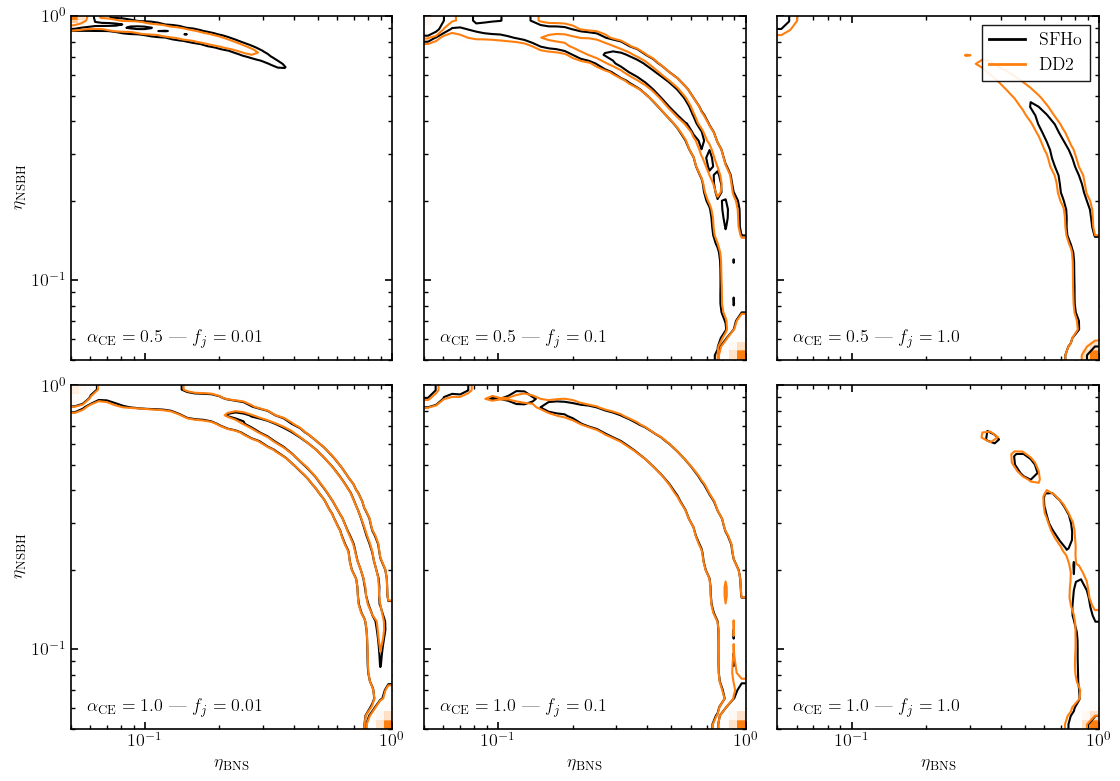

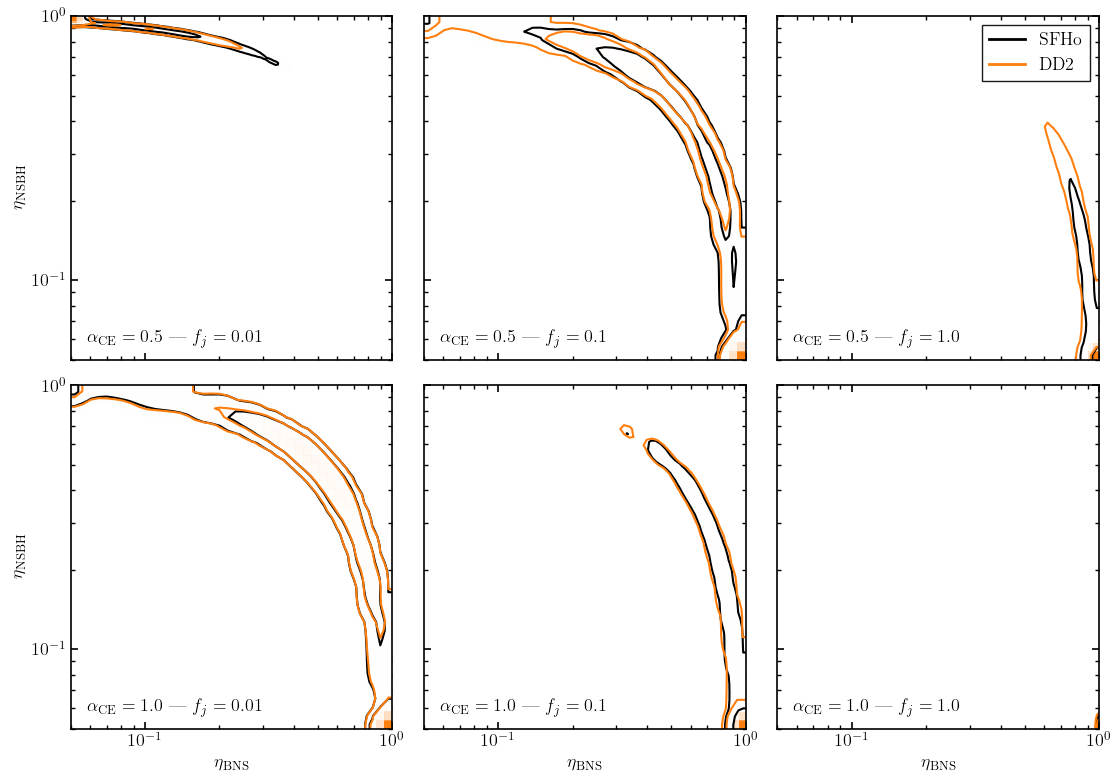

In [53]:
with open(OUTPUT_ROOT / "dic_in_universal.pkl", "rb") as f:
    dic_in_universal = pickle.load(f)
with open(OUTPUT_ROOT / "dic_in_lognormal.pkl", "rb") as f:
    dic_in_lognormal = pickle.load(f)

fig_u, axes_u = plot_posterior_grid(
    dictionary_of_results=dic_in_universal,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)
fig_u.savefig(IMAGES_FOLDER / f'universal_posterior_grid.pdf', bbox_inches='tight')

fig_ln, axes_ln = plot_posterior_grid(
    dictionary_of_results=dic_in_lognormal,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,  
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)
fig_ln.savefig(IMAGES_FOLDER / f'lognormal_posterior_grid.pdf', bbox_inches='tight')

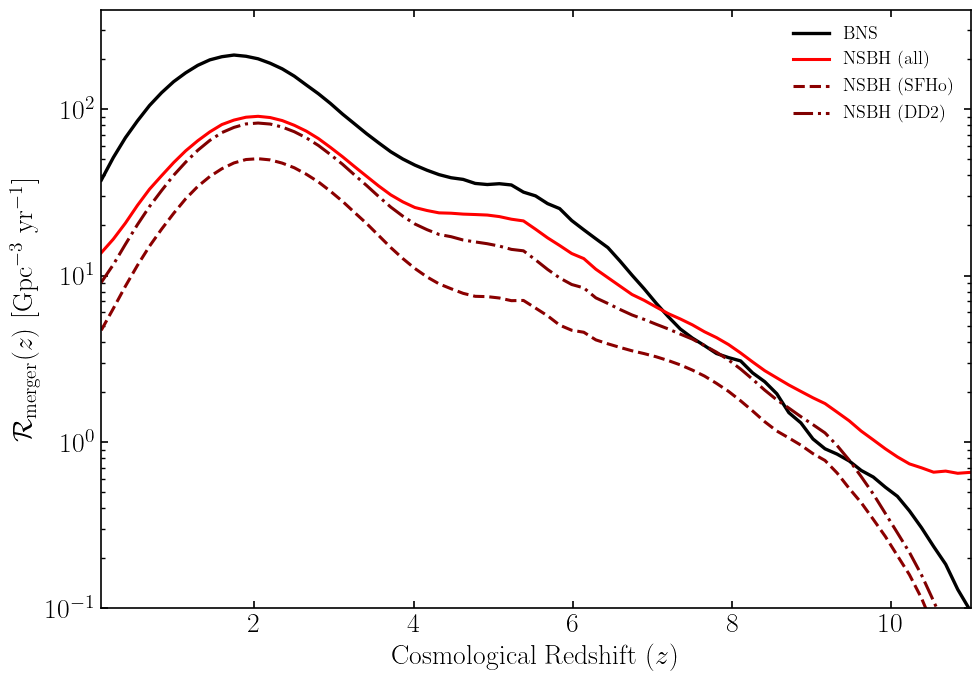

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MRD_CSV = OUTPUT_ROOT / 'mrd_comparison_long.csv'
PLOT_ALPHA = 'A0_5'

mrd_comparison_df = pd.read_csv(MRD_CSV)
plot_df = mrd_comparison_df[
    mrd_comparison_df['alpha'].eq(PLOT_ALPHA)
]

series_style = {
    'BNS': {
        'color': 'k',
        'linestyle': '-',
        'linewidth': 2.4,
        'label': 'BNS',
    },
    'NSBH': {
        'color': 'red',
        'linestyle': '-',
        'linewidth': 2.2,
        'label': 'NSBH (all)',
    },
    'NSBH cut SFHo': {
        'color': 'darkred',
        'linestyle': '--',
        'linewidth': 2.2,
        'label': 'NSBH (SFHo)',
    },
    'NSBH cut DD2': {
        'color': 'maroon',
        'linestyle': '-.',
        'linewidth': 2.2,
        'label': 'NSBH (DD2)',
    },
}

fig, ax = plt.subplots(figsize=(10, 7))

for series_name, style in series_style.items():
    curve = (
        plot_df[plot_df['series'].eq(series_name)]
        .sort_values('z')
    )

    mask = (
        curve['z'].lt(12)
        & curve['mrd'].gt(0)
        & np.isfinite(curve['z'])
        & np.isfinite(curve['mrd'])
    )

    if mask.any():
        ax.plot(
            curve.loc[mask, 'z'],
            curve.loc[mask, 'mrd'],
            **style,
        )

font_value = 20

ax.set_xlabel(
    r'Cosmological Redshift ($z$)',
    fontsize=font_value,
)
ax.set_ylabel(
    r'$\mathcal{R}_{\rm merger}(z)$ [Gpc$^{-3}$ yr$^{-1}$]',
    fontsize=font_value,
)
ax.set_yscale('log')
ax.set_xlim(0.07, 11)
ax.set_ylim(bottom=1e-1)
ax.tick_params(
    axis='both',
    which='both',
    labelsize=font_value,
)
ax.legend(
    fontsize=font_value * 0.65,
    frameon=False,
)

fig.tight_layout()

output_path = IMAGES_FOLDER / f'mrd_{PLOT_ALPHA}_both_EOS.pdf'
fig.savefig(output_path, bbox_inches='tight')

plt.show()

# Data prep, run this only if you have not already run the full analysis notebook. It will load the saved posterior files and prepare them for plotting.

In [47]:

def grid_run_name(alpha, fj, nsbh_population, geom_eff_name=GEOM_EFF_NAME):
    run_name = f'grid_likelihood_alpha_{alpha}_{fj}_{geom_eff_name}'
    if nsbh_population != 'fiducial_delayed_cut':
           run_name += f"_{nsbh_population.split('_')[-1]}"
    return run_name

def grid_file_for(alpha, fj, nsbh_population, output_root=OUTPUT_ROOT, geom_eff_name=GEOM_EFF_NAME):
    return output_root / grid_run_name(alpha, fj, nsbh_population, geom_eff_name) / 'grid_eval.npz'

def build_results_by_fj(alphas, fj_list, nsbh_populations, geom_eff_name=GEOM_EFF_NAME):
    results = {}
    missing = []
    for fj in fj_list:
        grid_files = []
        for nsbh_population in nsbh_populations:
            for alpha in alphas:
                grid_path = grid_file_for(alpha, fj, nsbh_population, geom_eff_name=geom_eff_name)
                grid_files.append(grid_path)
                if not grid_path.is_file():
                    missing.append(grid_path)
        results[fj] = {
            'grid_files': grid_files,
        }
    if missing:
        missing_text = '\n'.join(str(path) for path in missing)
        raise FileNotFoundError(f'Missing grid files:\n{missing_text}')
    return results

results_by_fj           = build_results_by_fj(ALPHA_all, FJ_LIST, NSBH_POPULATIONS)
results_by_fj_fixed     = build_results_by_fj(ALPHA_all, FJ_LIST, NSBH_POPULATIONS, geom_eff_name=GEOM_EFF_ALL[1])
results_by_fj_lognormal = build_results_by_fj(ALPHA_all, FJ_LIST, NSBH_POPULATIONS, geom_eff_name=GEOM_EFF_ALL[2])

import pickle
#save to results_by_fj.pkl
with open(OUTPUT_ROOT / "results_by_fj_midpoint.pkl", "wb") as f:
    pickle.dump(results_by_fj, f)
with open(OUTPUT_ROOT / "results_by_fj_fixedpkl", "wb") as f:
    pickle.dump(results_by_fj_fixed, f)
with open(OUTPUT_ROOT / "results_by_fj_lognormal.pkl", "wb") as f:
    pickle.dump(results_by_fj_lognormal, f)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Maximum log-likelihood value: -5.467496711958599
Maximum log-likelihood value: -5.401404555348903
Maximum log-likelihood value: -5.45019470747005
Maximum log-likelihood value: -5.0319680340731665
Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227
Using redshift model: samples_fiducial_

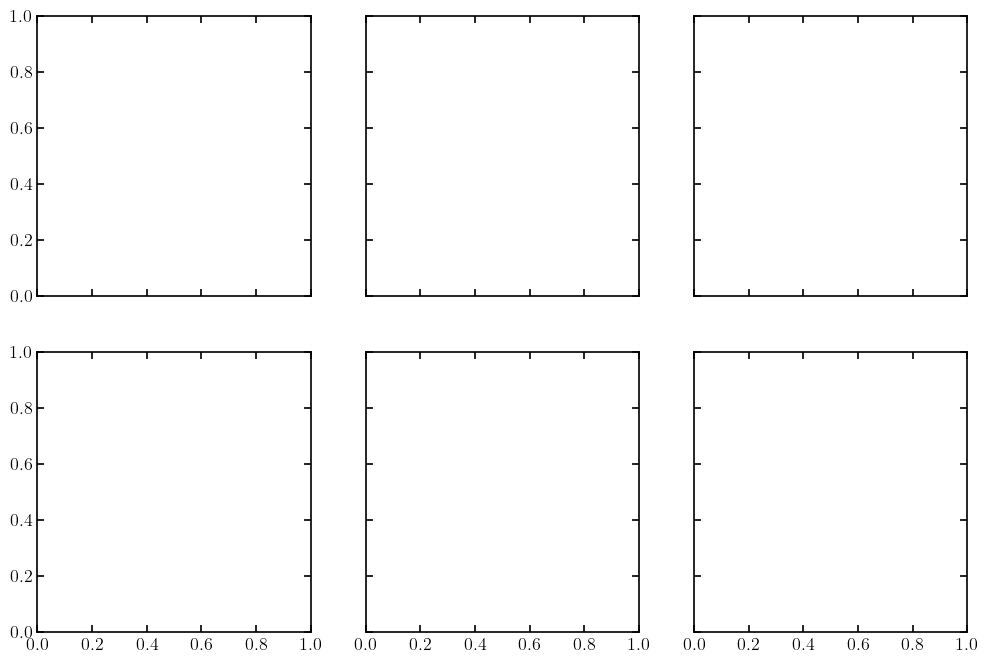

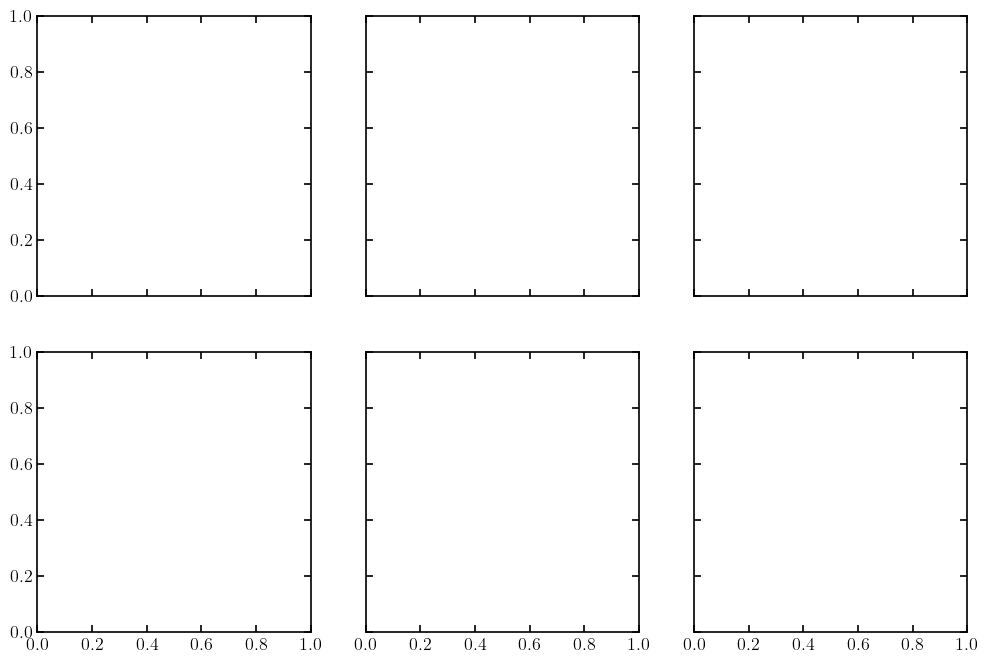

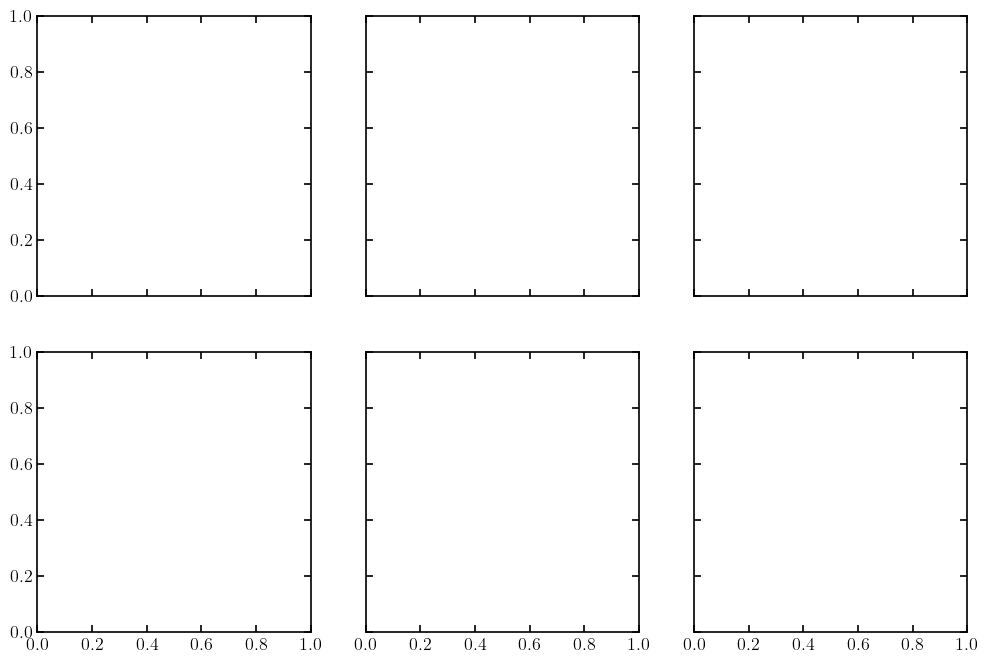

In [48]:
from src.nsbh.init import initialize_combined_simulation
datafiles           = Path('../../../datafiles')

def posterior_grid_prep(
    results_by_fj,
    fj_list,
    alpha_list,
    nsbh_populations,
    datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
):
    """Plot 2D posterior rate contours in a fj-by-alpha grid."""
    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list
    rows = len(row_values)
    cols = len(col_values)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    alpha_to_index = {alpha: idx for idx, alpha in enumerate(alpha_list)}
    triggered_years_cache = {}
    population_colors = ["k", "C1", "C2", "C3"]
    dictionary_of_results = {}

    for row_idx, row_value in enumerate(row_values):
        for col_idx, col_value in enumerate(col_values):
            alpha = col_value if swap_axes else row_value
            fj = row_value if swap_axes else col_value
            ax = axes[row_idx, col_idx]
            grid_bundle = results_by_fj[fj]
            grid_files_by_population = grid_bundle["grid_files"]

            if alpha not in triggered_years_cache:
                bns_params, _, _ = initialize_combined_simulation(
                    datafiles=datafiles,
                    params={"z_model": f"fiducial_delayed_{alpha}"},
                    nsbh_population=nsbh_populations[0],
                    nsbh_alpha=alpha,
                )
                triggered_years_cache[alpha] = bns_params.triggered_years

            triggered_years = triggered_years_cache[alpha]



            for pop_idx, population in enumerate(nsbh_populations):
                grid_file = grid_files_by_population[pop_idx * len(alpha_list) + alpha_to_index[alpha]]
                _, samples_mu_bns, samples_mu_nsbh = draw_grid_samples(grid_file)
                x = samples_mu_bns / triggered_years
                y = samples_mu_nsbh / triggered_years
                # save local rates too
                dictionary_of_results[(fj, alpha, population)] = {
                    "R_BNS": x,
                    "R_NSBH": y,
                }

    return dictionary_of_results

dic_in = posterior_grid_prep(
    results_by_fj=results_by_fj,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,
    datafiles=datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)

# save dictionary completely to OUTPUT_ROOT
import pickle
with open(OUTPUT_ROOT / "dic_in_midpoint.pkl", "wb") as f:
    pickle.dump(dic_in, f)

dic_in_universal = posterior_grid_prep(
    results_by_fj=results_by_fj_fixed,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,
    datafiles=datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)

dic_in_lognormal = posterior_grid_prep(
    results_by_fj=results_by_fj_lognormal,
    fj_list=FJ_LIST,
    alpha_list=ALPHA_all,
    nsbh_populations=NSBH_POPULATIONS,
    datafiles=datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)

with open(OUTPUT_ROOT / "dic_in_universal.pkl", "wb") as f:
    pickle.dump(dic_in_universal, f)

with open(OUTPUT_ROOT / "dic_in_lognormal.pkl", "wb") as f:
    pickle.dump(dic_in_lognormal, f)

# aLL PLOT

Maximum log-likelihood value: -5.467496711958599
Maximum log-likelihood value: -5.401404555348903


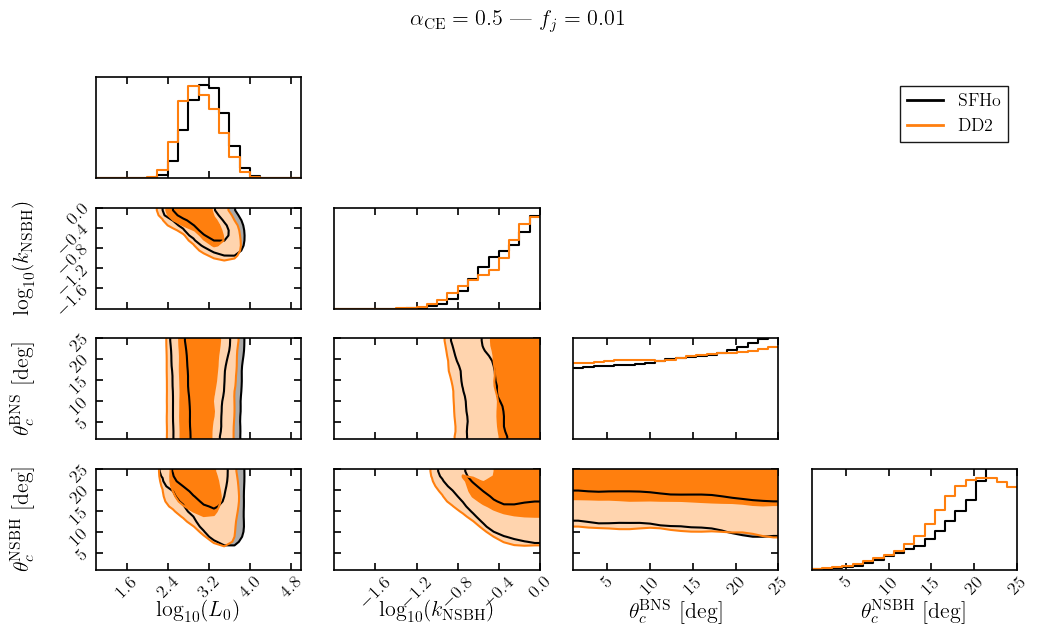

Maximum log-likelihood value: -5.046042501930752
Maximum log-likelihood value: -5.025691817669008


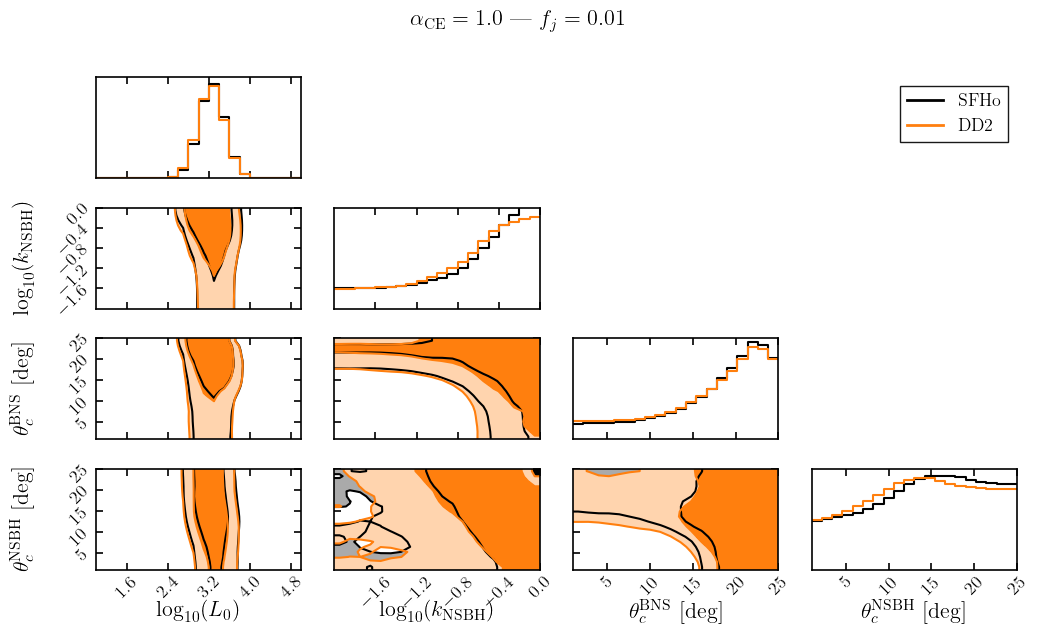

Maximum log-likelihood value: -5.45019470747005
Maximum log-likelihood value: -5.0319680340731665


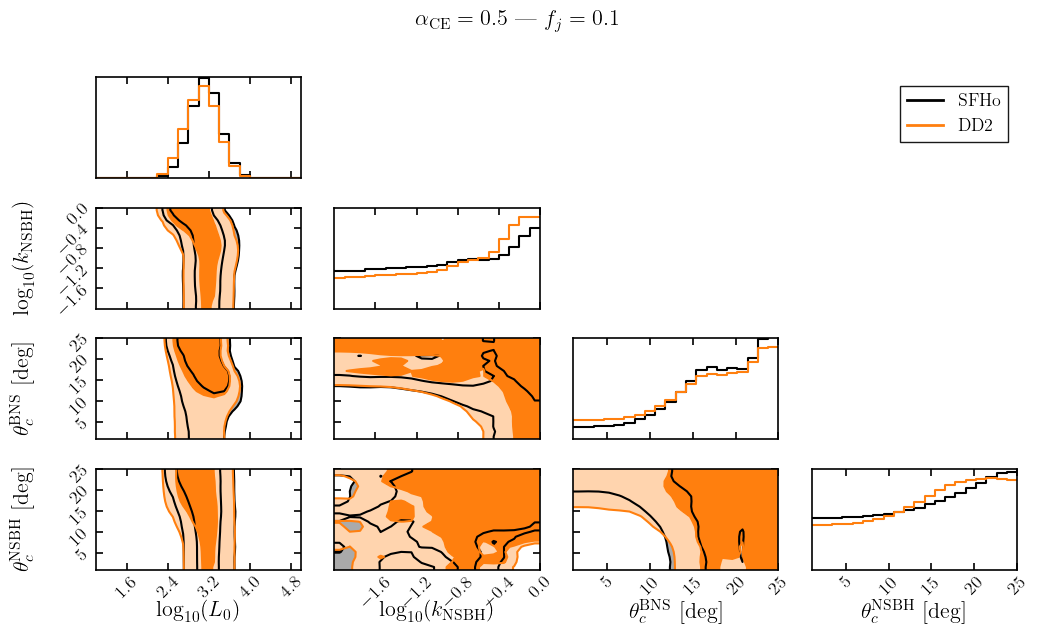

Maximum log-likelihood value: -5.046060972474332
Maximum log-likelihood value: -5.025825957699249


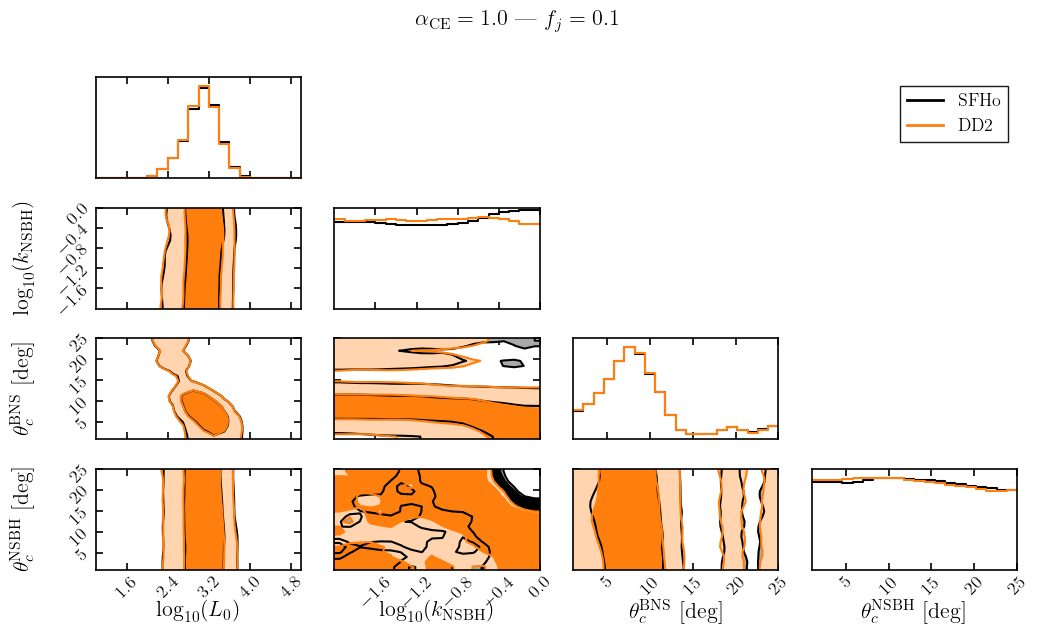

Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227


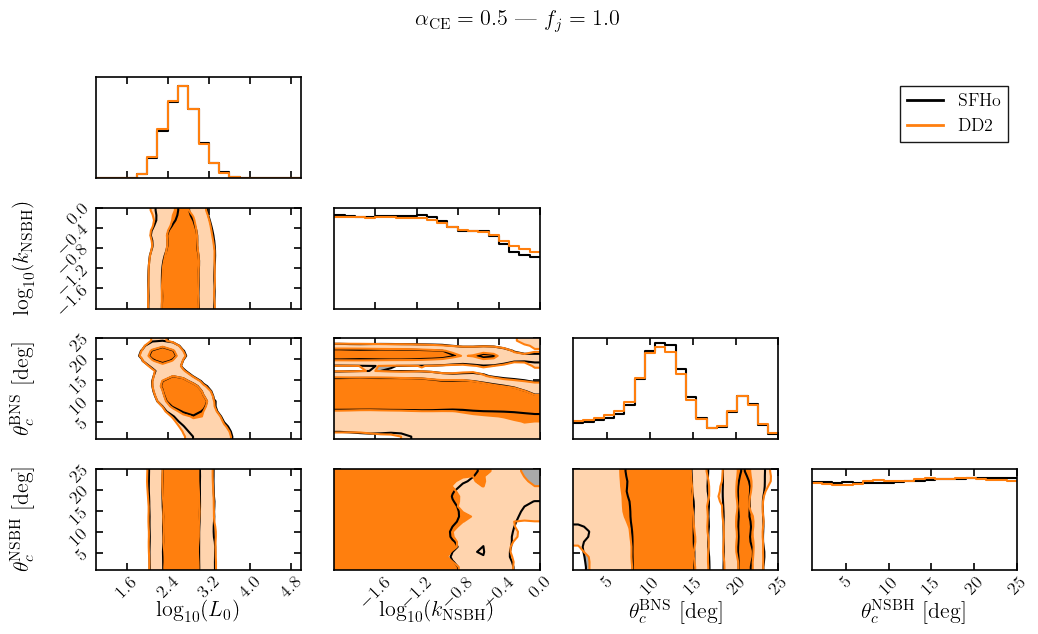

Maximum log-likelihood value: -5.7793594512221675
Maximum log-likelihood value: -5.7734909403514125


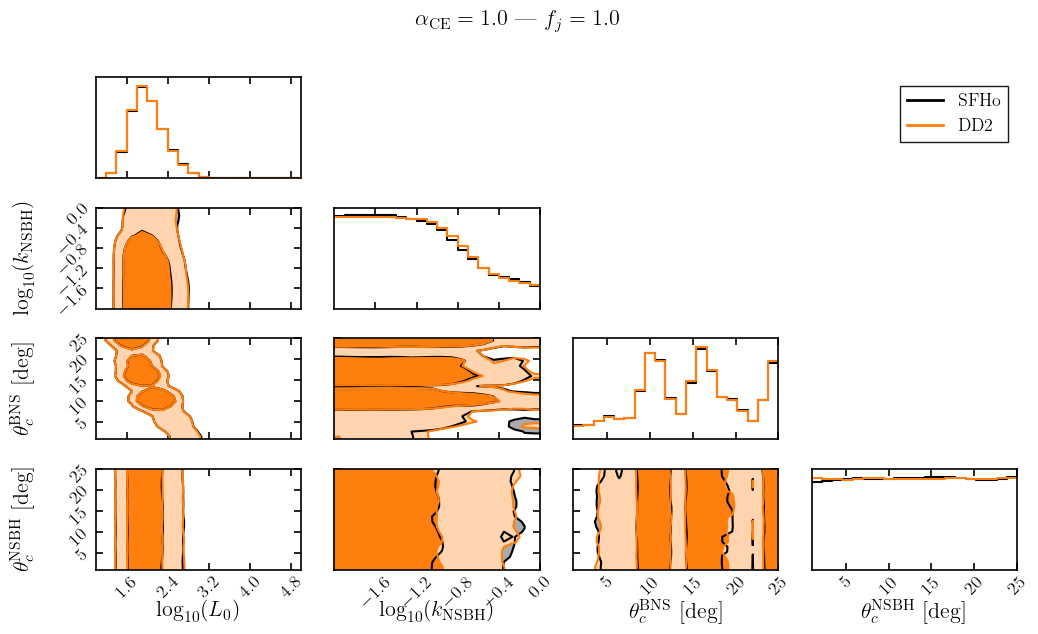

In [49]:
from pathlib import Path
import pickle
import sys

import corner
import matplotlib.pyplot as plt

sys.path.insert(0, "../../..")
sys.path.insert(0, "../..")
sys.path.insert(0, ".")

from mcmc_runner_a import draw_grid_samples

OUTPUT_ROOT = Path("Output_files")
IMAGES_FOLDER = Path("IMAGES")
IMAGES_FOLDER.mkdir(exist_ok=True)

#with open(OUTPUT_ROOT / "results_by_fj.pkl", "rb") as f:
#    results_by_fj = pickle.load(f)

#take universal results
with open(OUTPUT_ROOT / "results_by_fj_midpoint.pkl", "rb") as f:
    results_by_fj = pickle.load(f)

#FJ_VALUES = [0.1, 0.5, 1.0]
ALPHA_VALUES = ["A0.5", "A1.0"]

grid_labels = [
    r"$\log_{10}(L_0)$",
    r"$\log_{10}(k_{\mathrm{NSBH}})$",
    r"$\theta_c^{\mathrm{BNS}}$ [deg]",
    r"$\theta_c^{\mathrm{NSBH}}$ [deg]",
]

grid_ranges = [
    (1, 5),
    (-2, 0),
    (1, 25),
    (1, 25),
]

common_args = {
    "labels": grid_labels,
    "bins": 20,
    "smooth": 1,
    "smooth1d": 1,
    "range": grid_ranges,
    "plot_datapoints": False,
    "plot_density": True,
    "fill_contours": True,
    "levels": [0.68, 0.95],
    "title_kwargs": {"fontsize": 11},
    "label_kwargs": {"fontsize": FONTSIZE_UNIVERSAL},
}

scale_factor = 1.5
figsize_custom = (
    FIGSIZE_ROW[0] * scale_factor,
    FIGSIZE_ROW[1] * scale_factor,
)

n_alpha = len(ALPHA_VALUES)

for fj in FJ_LIST:
    grid_files = results_by_fj[fj]["grid_files"]

    for alpha_idx, alpha in enumerate(ALPHA_VALUES):
        # Files are ordered by population, then alpha:
        # [SFHo A0.5, SFHo A1.0, DD2 A0.5, DD2 A1.0]
        sfho_file = grid_files[alpha_idx]
        dd2_file = grid_files[n_alpha + alpha_idx]

        samples_sfho, _, _ = draw_grid_samples(sfho_file)
        samples_dd2, _, _ = draw_grid_samples(dd2_file)

        fig_in = plt.figure(figsize=figsize_custom)

        fig = corner.corner(
            samples_sfho,
            color="k",
            fig=fig_in,
            **common_args,
        )

        corner.corner(
            samples_dd2,
            color="C1",
            fig=fig,
            **common_args,
        )

        legend_handles = [
            plt.Line2D([0], [0], color="k", lw=2, label="SFHo"),
            plt.Line2D([0], [0], color="C1", lw=2, label="DD2"),
        ]

        axes = fig.get_axes()
        axes[3].legend(handles=legend_handles, loc="upper right")

        fig.suptitle(
            rf"$\alpha_{{\rm CE}}={alpha[1:]}$ | $f_j={fj}$",
            fontsize=FONTSIZE_UNIVERSAL,
        )

        fig.tight_layout(rect=(0, 0, 1, 0.97))

        output_path = (
            IMAGES_FOLDER
            / f"Appendix/midpoint_corner_plot_{alpha}_fj_{fj:g}_both_EOS.pdf"
        )
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight")

        plt.show()
        plt.close(fig)

Maximum log-likelihood value: -5.467496711958599
Maximum log-likelihood value: -5.401404555348903
Maximum log-likelihood value: -5.046042501930752
Maximum log-likelihood value: -5.025691817669008
Maximum log-likelihood value: -5.45019470747005
Maximum log-likelihood value: -5.0319680340731665
Maximum log-likelihood value: -5.046060972474332
Maximum log-likelihood value: -5.025825957699249
Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227
Maximum log-likelihood value: -5.7793594512221675
Maximum log-likelihood value: -5.7734909403514125


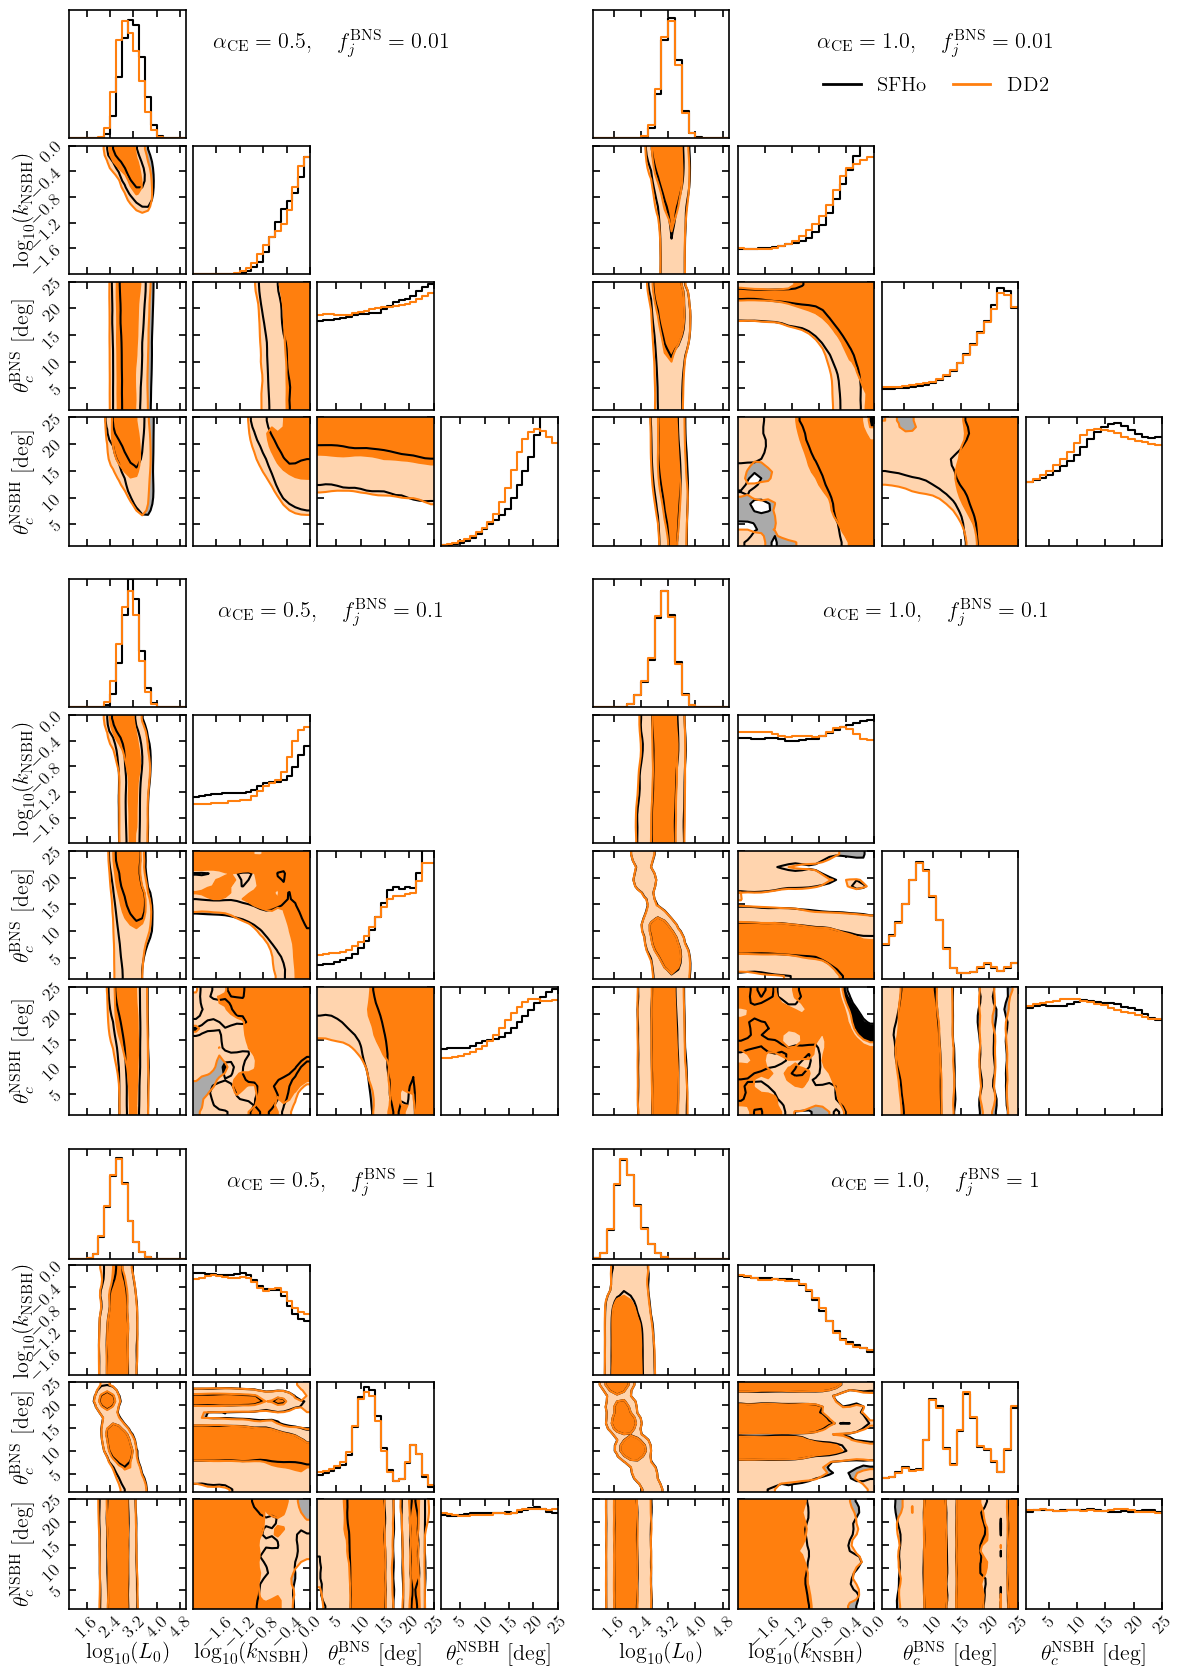

In [51]:
ndim = len(grid_labels)
n_rows = len(FJ_LIST)
n_cols = len(ALPHA_VALUES)

# One vector figure containing all six corner panels.
fig = plt.figure(figsize=(12, 17))

subfigs = fig.subfigures(
    nrows=n_rows,
    ncols=n_cols,
    squeeze=False,
    wspace=0.015,
    hspace=0.015,
)

legend_handles = [
    plt.Line2D([0], [0], color="k", lw=2, label="SFHo"),
    plt.Line2D([0], [0], color="C1", lw=2, label="DD2"),
]

# Used to link corresponding parameter axes between all six panels.
reference_axes = None

for row_idx, fj in enumerate(FJ_LIST):
    grid_files = results_by_fj[fj]["grid_files"]

    for col_idx, alpha in enumerate(ALPHA_VALUES):
        # Files are ordered as:
        # [SFHo A0.5, SFHo A1.0, DD2 A0.5, DD2 A1.0]
        sfho_file = grid_files[col_idx]
        dd2_file = grid_files[n_cols + col_idx]

        samples_sfho, _, _ = draw_grid_samples(sfho_file)
        samples_dd2, _, _ = draw_grid_samples(dd2_file)

        panel = subfigs[row_idx, col_idx]

        # corner expects ndim**2 axes in the supplied figure.
        panel_axes = panel.subplots(
            ndim,
            ndim,
            squeeze=False,
        )

        corner.corner(
            samples_sfho,
            color="k",
            fig=panel,
            **common_args,
        )

        corner.corner(
            samples_dd2,
            color="C1",
            fig=panel,
            **common_args,
        )

        # Actually share corresponding parameter axes between panels.
        # The y-axis of a diagonal histogram is not shared because it is
        # a density/count axis rather than a model-parameter axis.
        if reference_axes is None:
            reference_axes = panel_axes
        else:
            for i in range(ndim):
                for j in range(i + 1):
                    panel_axes[i, j].sharex(reference_axes[i, j])

                    if i != j:
                        panel_axes[i, j].sharey(reference_axes[i, j])

        # Put the panel title in the unused upper triangle, approximately
        # between the second and third inner columns.
        panel.text(
            0.61,
            0.955,
            (
                rf"$\alpha_{{\rm CE}}={alpha[1:]},\quad "
                rf"f_j^{{\rm BNS}}={fj:g}$"
            ),
            ha="center",
            va="top",
            fontsize=FONTSIZE_UNIVERSAL,
        )

        # The legend also fits in the unused upper triangle.
        if row_idx == 0 and col_idx == 1:
            panel.legend(
                handles=legend_handles,
                loc="upper center",
                bbox_to_anchor=(0.61, 0.905),
                ncol=2,
                frameon=False,
                fontsize=FONTSIZE_UNIVERSAL - 1,
                handlelength=1.8,
                columnspacing=1.2,
            )

        # Shared x labels/ticks: retain them only on the bottom row.
        if row_idx != n_rows - 1:
            for ax in panel_axes[-1, :]:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

        # Shared y labels/ticks: retain them only in the left column.
        if col_idx != 0:
            for ax in panel_axes[:, 0]:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)

        # Reclaim space formerly reserved for repeated labels and titles.
        panel.subplots_adjust(
            left=0.17 if col_idx == 0 else 0.035,
            bottom=0.17 if row_idx == n_rows - 1 else 0.035,
            right=0.99,
            top=0.99,
            wspace=0.06,
            hspace=0.06,
        )

output_path = (
    IMAGES_FOLDER
    / "Appendix/midpoint_corner_plot_all_fj_alpha_both_EOS.pdf"
)
output_path.parent.mkdir(parents=True, exist_ok=True)

# Do not call tight_layout here; it tends to fight the nested subfigures.
fig.savefig(output_path, bbox_inches="tight")
plt.show()
plt.close(fig)